# import #

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import astropy.units as u

from pta_replicator.simulate import simulate_pulsar, make_ideal
from pta_replicator.deterministic import add_cgw

from pint.models import get_model

from pathlib import Path

from copy import deepcopy

# parameter 

In [2]:
obstime = np.arange(53000, 56650, 14)

N_PSR = 25

T_seconds = (obstime[-1] - obstime[0]) * 86400.0
f = 1.0 / T_seconds
k0 = 5
delta = 0.5

source_ra = np.deg2rad(2.0)
source_dec = np.deg2rad(0.4)
gwphi = source_ra
gwtheta = np.pi / 2.0 - source_dec

# path

In [3]:
template_par = Path("data/JPSR00.par")
output_dir = Path("data/par")
output_dir.mkdir(parents=True, exist_ok=True)

# function

In [4]:
def fibonacci_sphere(n):
    i = np.arange(n)
    golden_ratio = (1 + np.sqrt(5)) / 2

    z = 1 - 2 * (i + 0.5) / n
    ra = np.mod(2 * np.pi * i / golden_ratio, 2 * np.pi)
    dec = np.arcsin(z)

    return ra, dec


ra_list, dec_list = fibonacci_sphere(N_PSR)

# workflow

In [5]:
for i, (ra, dec) in enumerate(zip(ra_list, dec_list)):
    model = get_model(template_par)

    name = f"J{i:02d}"

    model.PSR.value = name
    model.RAJ.quantity = ra * u.rad
    model.DECJ.quantity = dec * u.rad

    model.setup()
    model.validate()

    model.write_parfile(output_dir / f"{name}.par")

2026-07-22 01:53:33.755 | WARNING  | pint.models.model_builder:__call__:224 - UNITS is not specified. Assuming TDB...
2026-07-22 01:53:33.779 | WARNING  | pint.models.model_builder:__call__:224 - UNITS is not specified. Assuming TDB...
2026-07-22 01:53:33.803 | WARNING  | pint.models.model_builder:__call__:224 - UNITS is not specified. Assuming TDB...
2026-07-22 01:53:33.828 | WARNING  | pint.models.model_builder:__call__:224 - UNITS is not specified. Assuming TDB...
2026-07-22 01:53:33.855 | WARNING  | pint.models.model_builder:__call__:224 - UNITS is not specified. Assuming TDB...
2026-07-22 01:53:33.879 | WARNING  | pint.models.model_builder:__call__:224 - UNITS is not specified. Assuming TDB...
2026-07-22 01:53:33.906 | WARNING  | pint.models.model_builder:__call__:224 - UNITS is not specified. Assuming TDB...


2026-07-22 01:53:33.930 | WARNING  | pint.models.model_builder:__call__:224 - UNITS is not specified. Assuming TDB...
2026-07-22 01:53:33.955 | WARNING  | pint.models.model_builder:__call__:224 - UNITS is not specified. Assuming TDB...
2026-07-22 01:53:33.978 | WARNING  | pint.models.model_builder:__call__:224 - UNITS is not specified. Assuming TDB...
2026-07-22 01:53:34.006 | WARNING  | pint.models.model_builder:__call__:224 - UNITS is not specified. Assuming TDB...
2026-07-22 01:53:34.030 | WARNING  | pint.models.model_builder:__call__:224 - UNITS is not specified. Assuming TDB...
2026-07-22 01:53:34.053 | WARNING  | pint.models.model_builder:__call__:224 - UNITS is not specified. Assuming TDB...
2026-07-22 01:53:34.085 | WARNING  | pint.models.model_builder:__call__:224 - UNITS is not specified. Assuming TDB...
2026-07-22 01:53:34.115 | WARNING  | pint.models.model_builder:__call__:224 - UNITS is not specified. Assuming TDB...
2026-07-22 01:53:34.144 | WARNING  | pint.models.model_b

In [6]:
parfiles = sorted(output_dir.glob("*.par"))

print(f"生成了 {len(parfiles)} 个 par 文件")

model = get_model(parfiles[0])

print("PSR :", model.PSR.value)
print("RA  :", model.RAJ.quantity)
print("DEC :", model.DECJ.quantity)
print("F0  :", model.F0.quantity)

生成了 25 个 par 文件
PSR : J00
RA  : 0h00m00s
DEC : 73d44m23.26305008s
F0  : 205.530696088273 Hz


In [7]:
psrs = []

for parfile in parfiles:
    psr = simulate_pulsar(
        parfile=str(parfile),
        obstimes=obstime,
        toaerr=0.1,       # μs
        freq=1440.0,      # MHz
        observatory="AXIS",
        ephem="DE440",
    )

    make_ideal(psr)
    psrs.append(psr)

print("脉冲星数量：", len(psrs))
print("每颗 TOA 数量：", len(psrs[0].toas))

2026-07-22 01:53:34.477 | INFO     | pint.simulation:get_fake_toa_clock_versions:106 - Using CLOCK = BIPM2016 from the given model
2026-07-22 01:53:34.488 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2026-07-22 01:53:34.489 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)


2026-07-22 01:53:34.498 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2016) clock correction (~27 us)
2026-07-22 01:53:34.499 | INFO     | pint.observatory:_load_bipm_clock:119 - Loading BIPM clock version bipm2016
2026-07-22 01:53:34.501 | DEBUG    | pint.observatory.clock_file:__init__:812 - Global clock file tai2tt_bipm2016.clk saving kwargs={'bogus_last_correction': True, 'valid_beyond_ends': False}
2026-07-22 01:53:34.503 | DEBUG    | pint.observatory.clock_file:read_tempo2_clock_file:463 - Loading TEMPO2-format observatory clock correction file tai2tt_bipm2016.clk (/home/jiyu/.astropy/cache/download/url/24390aa791a89928bc8cd844835777e3/contents) with bogus_last_correction=True
2026-07-22 01:53:34.506 | INFO     | pint.observatory:find_clock_file:973 - Using global clock file for tai2tt_bipm2016.clk with bogus_last_correction=True
2026-07-22 01:53:34.507 | INFO     | pint.observatory.topo_obs:clock_corrections:354 - Observatory axis requires no clo

脉冲星数量： 25
每颗 TOA 数量： 261


In [8]:
fgw = (k0 + delta) * f

print("1/T =", f, "Hz")
print("CW frequency =", fgw, "Hz")

1/T = 3.17969067969068e-09 Hz
CW frequency = 1.748829873829874e-08 Hz


In [9]:
for psr in psrs:
    add_cgw(
        psr=psr,
        gwtheta=gwtheta,
        gwphi=gwphi,
        mc=1.0e9,             # solar masses
        dist=100.0,           # Mpc
        fgw=fgw,
        phase0=0.0,
        psi=0.0,
        inc=np.pi / 3.0,
        psrTerm=False,        # 只保留 Earth term
        evolve=False,         # 单色 CW
        phase_approx=False,
        tref=obstime[0] * 86400.0,
        signal_name='cw',
    )

2026-07-22 01:53:51.815 | DEBUG    | pint.toa:compute_TDBs:2278 - Computing TDB columns.
2026-07-22 01:53:51.817 | DEBUG    | pint.toa:compute_TDBs:2280 - tdb column already exists. Deleting...
2026-07-22 01:53:51.817 | DEBUG    | pint.toa:compute_TDBs:2283 - tdbld column already exists. Deleting...
2026-07-22 01:53:51.818 | DEBUG    | pint.toa:compute_TDBs:2299 - Using EPHEM = DE440 for TDB calculation.
2026-07-22 01:53:51.839 | DEBUG    | pint.toa:compute_posvels:2379 - Computing PosVels of observatories and Earth, using DE440
2026-07-22 01:53:51.841 | DEBUG    | pint.toa:compute_posvels:2384 - Column ssb_obs_pos already exists. Removing...
2026-07-22 01:53:51.841 | DEBUG    | pint.toa:compute_posvels:2384 - Column ssb_obs_vel already exists. Removing...
2026-07-22 01:53:51.842 | DEBUG    | pint.toa:compute_posvels:2384 - Column obs_sun_pos already exists. Removing...
2026-07-22 01:53:51.848 | INFO     | pint.solar_system_ephemerides:load_kernel:194 - Set solar system ephemeris to de

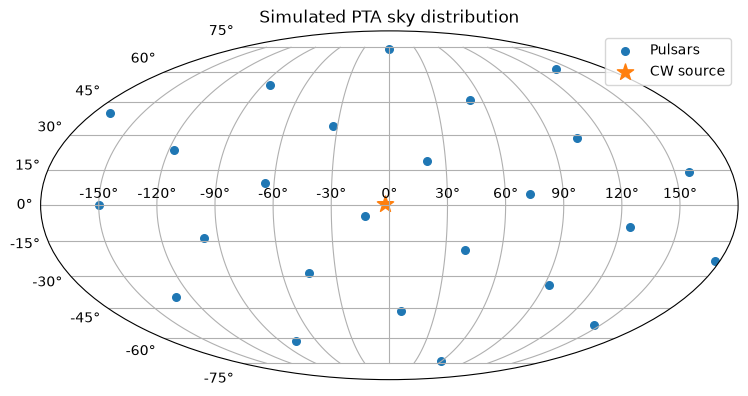

In [10]:
ra = np.array([
    psr.model.RAJ.quantity.to_value(u.rad)
    for psr in psrs
])

dec = np.array([
    psr.model.DECJ.quantity.to_value(u.rad)
    for psr in psrs
])

# 将 RA 转换到 [-π, π]
ra_wrapped = (ra + np.pi) % (2.0 * np.pi) - np.pi
source_ra_wrapped = (source_ra + np.pi) % (2.0 * np.pi) - np.pi

fig = plt.figure(figsize=(9, 5))
ax = fig.add_subplot(111, projection="mollweide")

# 负号使 RA 按天文惯例向左增大
ax.scatter(-ra_wrapped, dec, s=30, label="Pulsars")
ax.scatter(
    -source_ra_wrapped,
    source_dec,
    marker="*",
    s=150,
    label="CW source",
)

ax.grid()
ax.legend()
ax.set_title("Simulated PTA sky distribution")

plt.show()

In [11]:
cw_data_dir = Path("data/cw_partim")
cw_data_dir.mkdir(parents=True, exist_ok=True)

for psr in psrs:
    psr.write_partim(
        outpar=cw_data_dir / f"{psr.name}.par",
        outtim=cw_data_dir / f"{psr.name}.tim",
        tempo2=True,
    )

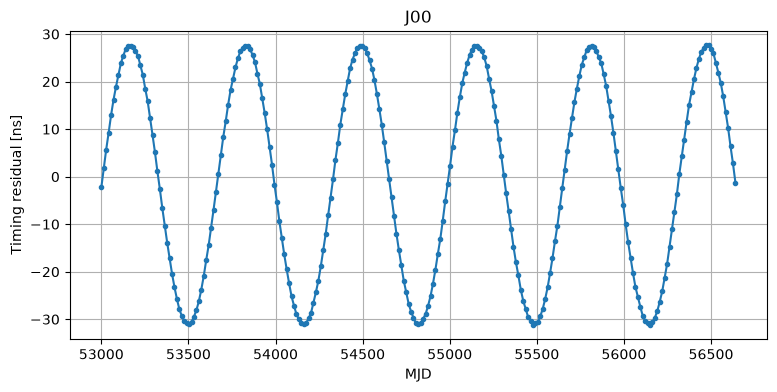

In [12]:
psr = psrs[0]

toa_mjd = psr.toas.get_mjds().value
residual_ns = psr.residuals.time_resids.to_value(u.ns)

plt.figure(figsize=(9, 4))

plt.plot(toa_mjd, residual_ns, ".-")

plt.xlabel("MJD")
plt.ylabel("Timing residual [ns]")
plt.title(psr.name)
plt.grid()

plt.show()

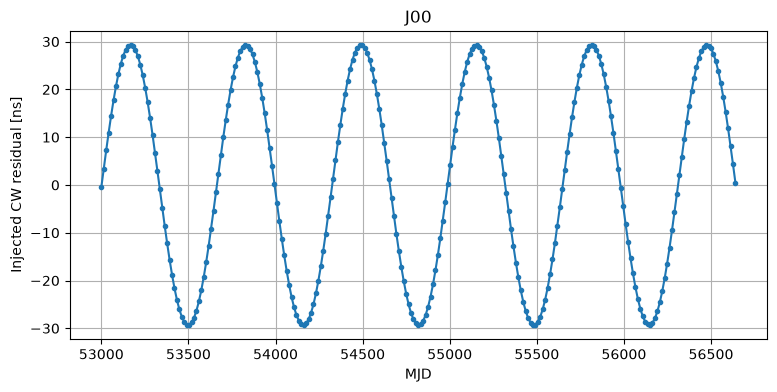

In [13]:
cw_residual = psr.added_signals_time['J00_cw'].to_value(u.ns)
toa_mjd = psr.toas.get_mjds().value

plt.figure(figsize=(9, 4))

plt.plot(toa_mjd, cw_residual, ".-")
plt.xlabel("MJD")
plt.ylabel("Injected CW residual [ns]")
plt.title(psr.name)
plt.grid()

plt.show()

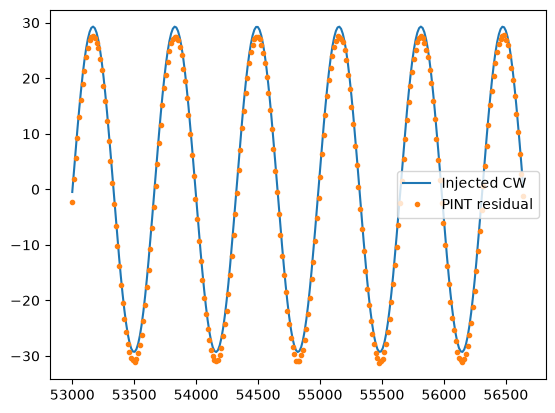

In [14]:
total_residual = psr.residuals.time_resids.to_value(u.ns)

plt.plot(toa_mjd, cw_residual, label="Injected CW")
plt.plot(toa_mjd, total_residual, ".", label="PINT residual")
plt.legend()
plt.show()

In [15]:
difference = total_residual - cw_residual

print("max difference [ns]:", np.max(np.abs(difference)))
print("RMS difference [ns]:", np.std(difference))

max difference [ns]: 1.9704757491514976742
RMS difference [ns]: 0.12636523307854986518


In [16]:
diff = total_residual - cw_residual

relative_rms = np.std(diff) / np.std(cw_residual)
relative_max = np.max(np.abs(diff)) / np.max(np.abs(cw_residual))

print(relative_rms, relative_max)

0.006130861423438373579 0.06724678183882909239


Text(0.5, 0, 'MJD')

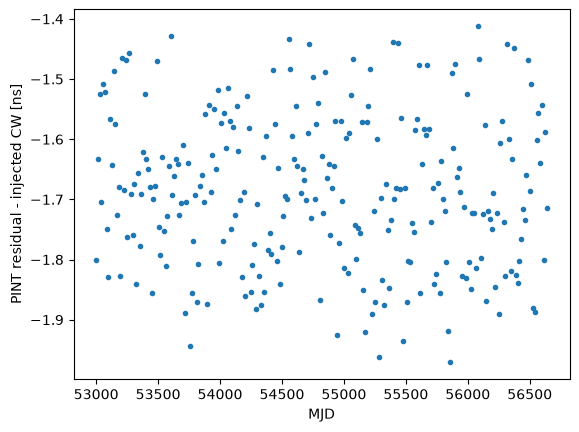

In [17]:
plt.plot(toa_mjd, diff, ".")
plt.ylabel("PINT residual - injected CW [ns]")
plt.xlabel("MJD")

In [18]:
residual_amplitude = 0.5 * np.ptp(cw_residual)
print(residual_amplitude, "ns")

29.300337230999915 ns


In [22]:
from enterprise.pulsar import Pulsar

enterprise_psrs = [
    Pulsar(
        p.toas,
        p.model,
        timing_package="pint",
        planets=False,
    )
    for p in psrs
]

2026-07-22 02:02:59.645 | DEBUG    | pint.models.absolute_phase:get_TZR_toa:101 - Creating and dealing with the single TZR_toa for absolute phase
2026-07-22 02:02:59.647 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2026-07-22 02:02:59.647 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2026-07-22 02:02:59.649 | DEBUG    | pint.toa:compute_TDBs:2278 - Computing TDB columns.
2026-07-22 02:02:59.649 | DEBUG    | pint.toa:compute_TDBs:2299 - Using EPHEM = DE440 for TDB calculation.
2026-07-22 02:02:59.650 | DEBUG    | pint.toa:compute_posvels:2379 - Computing PosVels of observatories and Earth, using DE440
2026-07-22 02:02:59.652 | DEBUG    | pint.toa:compute_posvels:2432 - SSB obs pos [0. 0. 0.] m
2026-07-22 02:02:59.652 | INFO     | pint.solar_system_ephemerides:load_kernel:194 - Set solar system ephemeris to de440 through astropy
2026-07-22 02:02:59.653 | DEBUG    | pint.toa:compute_posvels:2446 - Add

In [23]:
for psr in enterprise_psrs[:3]:
    print(
        psr.name,
        len(psr.toas),
        psr.toas.min(),
        psr.toas.max(),
    )

J00 261 4579200239.467906 4893696271.779491
J01 261 4579200104.933258 4893696069.911834
J02 261 4579200484.73054 4893696491.279551
